# Análisis Exploratorio de Datos: Casos Positivos COVID-19 en Atlántico

**Estudiantes:**
- Juan Esteban Garcia Gomez
- Luis Esteban Mariño

---

## 1. Introducción

La pandemia de COVID-19 representó uno de los mayores desafíos sanitarios del siglo XXI. El departamento del Atlántico, como uno de los más poblados y con mayor actividad económica de Colombia, fue uno de los territorios más afectados en el país. Comprender la dinámica de contagio, recuperación y mortalidad en esta región resulta fundamental para la toma de decisiones en salud pública y para el diseño de estrategias de respuesta ante futuras emergencias sanitarias.

El presente análisis exploratorio de datos trabaja sobre un conjunto de registros de casos positivos de COVID-19 en el Atlántico, reportados por el Instituto Nacional de Salud (INS) a través de la plataforma de Datos Abiertos de Colombia, con fechas comprendidas entre el **20 de marzo de 2020** y el **17 de enero de 2024**. El archivo contiene un total de **419.061 registros** con **23 variables** que incluyen información demográfica, fechas relevantes del proceso de enfermedad, tipo de contagio y desenlace clínico.

---

## 2. Contexto

El COVID-19, causado por el virus SARS-CoV-2, fue declarado pandemia por la OMS en marzo de 2020. En Colombia, el primer caso se confirmó el 6 de marzo de 2020 y la enfermedad se dispersó rápidamente por todo el territorio nacional. El Atlántico, con Barranquilla como su capital y principal centro urbano, concentró una parte significativa de los casos del Caribe colombiano.

El análisis de los datos del INS permite entender no solo el volumen de casos, sino también la distribución geográfica al interior del departamento, los patrones por sexo y edad, las vías de contagio predominantes y la evolución temporal de la pandemia a lo largo de sus distintas olas.

---

## 3. Planteamiento del Problema

¿Cuál fue el comportamiento de los casos positivos de COVID-19 en el departamento del Atlántico entre 2020 y 2024, en términos de distribución temporal, geográfica, demográfica, tipo de contagio y desenlace clínico, y qué factores se asocian con una mayor tasa de mortalidad o con tiempos de recuperación prolongados?

---

## 4. Objetivos

### Objetivo General
Realizar un análisis exploratorio de los casos positivos de COVID-19 registrados en el departamento del Atlántico entre 2020 y 2024, con el fin de identificar patrones relevantes en la distribución de contagios, mortalidad y recuperación.

### Objetivos Específicos
1. Describir la distribución demográfica (edad y sexo) de los casos positivos de COVID-19 en el Atlántico.
2. Analizar la evolución temporal de los casos positivos para identificar picos y tendencias a lo largo del periodo de estudio.
3. Identificar los municipios con mayor número de casos y las diferencias en tasas de mortalidad entre ellos.
4. Determinar los tipos de contagio más frecuentes y su distribución relativa.
5. Caracterizar los tiempos de recuperación y de fallecimiento a partir de indicadores estadísticos descriptivos.
6. Construir un modelo predictivo inicial que permita estimar la probabilidad de fallecimiento de un paciente con base en sus características registradas.

---

## 5. Justificación

El análisis exploratorio de datos sobre COVID-19 en el Atlántico tiene relevancia académica y práctica. Desde el punto de vista académico, permite aplicar técnicas de análisis de datos reales, con problemas propios de datos longitudinales, valores faltantes y variables heterogéneas. Desde la perspectiva práctica, los resultados pueden aportar evidencia sobre las poblaciones más vulnerables, los municipios con menor capacidad de respuesta y los periodos de mayor carga en el sistema de salud departamental.

Adicionalmente, dado que los datos contienen información sobre el desenlace de cada caso (recuperado o fallecido), es posible avanzar hacia un objetivo predictivo, que es uno de los propósitos del presente trabajo.

---

## 6. Marco Teórico

### COVID-19 y sus determinantes
El COVID-19 es una enfermedad infecciosa causada por el SARS-CoV-2. Su transmisión ocurre principalmente por vía respiratoria a través de gotas y aerosoles. La gravedad clínica varía desde casos asintomáticos hasta neumonías severas con desenlace fatal, siendo la edad avanzada y las comorbilidades los principales factores de riesgo para enfermedad grave.

### Análisis Exploratorio de Datos (EDA)
El EDA es un enfoque estadístico cuyo objetivo es resumir las principales características de un conjunto de datos, frecuentemente mediante métodos visuales. Propuesto por Tukey (1977), el EDA incluye la descripción de distribuciones, la identificación de valores atípicos, la exploración de relaciones entre variables y el tratamiento de datos faltantes. No debe confundirse con el proceso ETL (Extract, Transform, Load), que comprende las transformaciones y preparación previa de los datos para el análisis.

### Operacionalización de Variables
La operacionalización de variables consiste en definir de manera precisa cómo se medirá cada concepto abstracto dentro de la investigación. Para este análisis, las variables han sido clasificadas en cuantitativas y cualitativas, con sus respectivos tipos de medida, como se detalla en la sección de descripción de variables.

## 7. Descripción y Operacionalización de Variables

A continuación se presenta la operacionalización de todas las variables del dataset, indicando su nombre, tipo (cuantitativa/cualitativa), nivel de medida y descripción.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns       
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Tabla de operacionalización de variables
variables = {
    'Variable': [
        'fecha reporte web', 'ID de caso', 'Fecha de notificacion',
        'Código DIVIPOLA departamento', 'Nombre departamento',
        'Codigo DIVIPOLA municipio', 'Nombre municipio',
        'Edad', 'Unidad de medida de edad', 'Sexo',
        'Tipo de contagio', 'Ubicacion del caso', 'Estado',
        'Codigo ISO del país', 'Nombre del Pais',
        'Recuperado', 'Fecha de inicio de sintomas',
        'Fecha de muerte', 'Fecha de diagnostico',
        'Fecha de recuperacion', 'Tipo de recuperacion',
        'Pertenencia Etnica', 'Nombre del grupo Etnico'
    ],
    'Tipo': [
        'Cualitativa', 'Cuantitativa', 'Cualitativa',
        'Cualitativa', 'Cualitativa',
        'Cualitativa', 'Cualitativa',
        'Cuantitativa', 'Cualitativa', 'Cualitativa',
        'Cualitativa', 'Cualitativa', 'Cualitativa',
        'Cualitativa', 'Cualitativa',
        'Cualitativa', 'Cualitativa',
        'Cualitativa', 'Cualitativa',
        'Cualitativa', 'Cualitativa',
        'Cualitativa', 'Cualitativa'
    ],
    'Nivel de medida': [
        'Nominal', 'Razón', 'Nominal',
        'Nominal', 'Nominal',
        'Nominal', 'Nominal',
        'Razón', 'Ordinal', 'Nominal',
        'Nominal', 'Nominal', 'Nominal',
        'Nominal', 'Nominal',
        'Nominal', 'Nominal',
        'Nominal', 'Nominal',
        'Nominal', 'Nominal',
        'Nominal', 'Nominal'
    ],
    'Descripción': [
        'Fecha en que se diligenció el caso en la web del INS',
        'Número único identificador del caso positivo',
        'Fecha en que se reportó el resultado positivo del paciente',
        'Código DIVIPOLA del departamento donde se detectó el caso',
        'Nombre del departamento donde se detectó el caso',
        'Código DIVIPOLA del municipio donde se realizó la prueba',
        'Nombre del municipio donde el paciente realizó la prueba',
        'Edad del paciente al momento del diagnóstico',
        'Unidad en que se expresa la edad (1=años, 2=meses, 3=días)',
        'Sexo biológico del paciente (M/F)',
        'Mecanismo de transmisión (Comunitario, Relacionado, Importado)',
        'Lugar donde se encontraba el paciente durante el contagio',
        'Estado clínico del paciente al momento del reporte',
        'Código ISO del país de origen del paciente',
        'País de origen del paciente',
        'Desenlace del caso (Recuperado / Fallecido)',
        'Fecha en que el paciente presentó los primeros síntomas',
        'Fecha de fallecimiento del paciente',
        'Fecha en que se recibió el diagnóstico positivo',
        'Fecha en que el paciente fue dado de alta como recuperado',
        'Mecanismo de confirmación de recuperación',
        'Pertenencia étnica (1=Indígena, 2=ROM, 3=Raizal, 4=Palenquero, 5=Negro, 6=Otro)',
        'Nombre del grupo étnico del paciente (si aplica)'
    ]
}

df_vars = pd.DataFrame(variables)
df_vars.style.set_properties(**{'text-align': 'left'}).set_table_styles(
    [{'selector': 'th', 'props': [('text-align', 'center'), ('background-color', '#2c7bb6'), ('color', 'white')]}]
)

,Variable,Tipo,Nivel de medida,Descripción
0,fecha reporte web,Cualitativa,Nominal,Fecha en que se diligenció el caso en la web del INS
1,ID de caso,Cuantitativa,Razón,Número único identificador del caso positivo
2,Fecha de notificacion,Cualitativa,Nominal,Fecha en que se reportó el resultado positivo del paciente
3,Código DIVIPOLA departamento,Cualitativa,Nominal,Código DIVIPOLA del departamento donde se detectó el caso
4,Nombre departamento,Cualitativa,Nominal,Nombre del departamento donde se detectó el caso
5,Codigo DIVIPOLA municipio,Cualitativa,Nominal,Código DIVIPOLA del municipio donde se realizó la prueba
6,Nombre municipio,Cualitativa,Nominal,Nombre del municipio donde el paciente realizó la prueba
7,Edad,Cuantitativa,Razón,Edad del paciente al momento del diagnóstico
8,Unidad de medida de edad,Cualitativa,Ordinal,"Unidad en que se expresa la edad (1=años, 2=meses, 3=días)"
9,Sexo,Cualitativa,Nominal,Sexo biológico del paciente (M/F)


---

## 8. Carga y Preparación de Datos

In [2]:
df = pd.read_csv(
    "covid_colombia2.csv",
    sep=";"
)
df.head()

,fecha reporte web,ID de caso,Fecha de notificacion,Codigo DIVIPOLA departamento,Nombre departamento,Codigo DIVIPOLA municipio,Nombre municipio,Edad,Unidad de medida de edad,Sexo,...,Codigo ISO del país,Nombre del Pais,Recuperado,Fecha de inicio de sintomas,Fecha de muerte,Fecha de diagnostico,Fecha de recuperacion,Tipo de recuperacion,Pertenencia Etnica,Nombre del grupo Etnico
0,16/03/2020 0:00,59,14/03/2020 0:00,8.001,BARRANQUILLA,8.001,BARRANQUILLA,20.0,1.0,M,...,724.0,ESPAÑA,Recuperado,13/03/2020 0:00,NaN,16/03/2020 0:00,27/03/2020 0:00,PCR,6.0,NaN
1,16/03/2020 0:00,61,16/03/2020 0:00,8.001,BARRANQUILLA,8.001,BARRANQUILLA,21.0,1.0,M,...,724.0,ESPAÑA,Recuperado,10/03/2020 0:00,NaN,16/03/2020 0:00,24/03/2020 0:00,PCR,6.0,NaN
2,24/03/2020 0:00,324,16/03/2020 0:00,8.001,BARRANQUILLA,8.001,BARRANQUILLA,57.0,1.0,M,...,591.0,PANAMA,Recuperado,16/03/2020 0:00,NaN,24/03/2020 0:00,30/03/2020 0:00,PCR,6.0,NaN
3,19/03/2020 0:00,127,18/03/2020 0:00,8.001,BARRANQUILLA,8.001,BARRANQUILLA,30.0,1.0,F,...,NaN,NaN,Recuperado,16/03/2020 0:00,NaN,19/03/2020 0:00,29/03/2020 0:00,PCR,6.0,NaN
4,19/03/2020 0:00,126,18/03/2020 0:00,8.001,BARRANQUILLA,8.001,BARRANQUILLA,52.0,1.0,F,...,840.0,ESTADOS UNIDOS DE AMÉRICA,Recuperado,6/03/2020 0:00,NaN,19/03/2020 0:00,31/03/2020 0:00,PCR,5.0,NaN


---

## 9. ETL: Transformación y Preparación de los Datos

En esta sección se documentan las transformaciones aplicadas al dataset **antes** de realizar el análisis exploratorio. Estas operaciones hacen parte del proceso de ETL (Extract, Transform, Load) y son necesarias para garantizar la calidad y consistencia de los datos. Se diferencia intencionalmente del EDA para no mezclar limpieza con análisis.

Las transformaciones realizadas son:
1. Eliminación de filas completamente vacías.
2. Conversión de fechas al tipo `datetime`.
3. Creación de la variable **Dias de recuperacion**: diferencia entre fecha de recuperación y fecha de inicio de síntomas.
4. Creación de la variable **Dias hasta fallecimiento**: diferencia entre fecha de muerte y fecha de inicio de síntomas.
5. Imputación de valores faltantes en `Nombre del Pais` como "Colombia".
6. Eliminación de la columna `Codigo ISO del país` por alto porcentaje de nulos y poca utilidad.
7. Imputación de valores faltantes en `Recuperado` como "Fallecido" (corresponden a registros con fecha de muerte).
8. Estandarización de la categoría "fallecido" → "Fallecido" (consistencia tipográfica).
9. Estandarización de nombres de municipios.
10. Conversión de la variable `Edad` a años (unificando registros en meses y días), generando la variable `Edad_años`.

In [3]:
# 1. Eliminar filas completamente vacías
df = df.dropna(how="all")
print(f"Dimensiones después de limpieza: {df.shape}")

Dimensiones después de limpieza: (419061, 23)


In [4]:
# 2-3. Conversión de fechas y creación de variable 'Dias de recuperacion'
df["Fecha de inicio de sintomas"] = pd.to_datetime(df['Fecha de inicio de sintomas'], dayfirst=True)
df["Fecha de recuperacion"] = pd.to_datetime(df["Fecha de recuperacion"], dayfirst=True)

df['Dias de recuperacion'] = (
    df['Fecha de recuperacion'] - df['Fecha de inicio de sintomas']
).dt.days

print("Variable 'Dias de recuperacion' creada correctamente.")

Variable 'Dias de recuperacion' creada correctamente.


In [5]:
# 4. Creación de variable 'Dias hasta fallecimiento'
df["Fecha de muerte"] = pd.to_datetime(df["Fecha de muerte"], dayfirst=True)
df["dias hasta fallecimiento"] = (
    df["Fecha de muerte"] - df["Fecha de inicio de sintomas"]
).dt.days

print("Variable 'dias hasta fallecimiento' creada correctamente.")

Variable 'dias hasta fallecimiento' creada correctamente.


In [6]:
# 5-8. Imputación y estandarización
df["Nombre del Pais"] = df["Nombre del Pais"].fillna("Colombia")
df = df.drop(columns=["Codigo ISO del país"])
df["Recuperado"] = df["Recuperado"].fillna("Fallecido")
df["Recuperado"] = df["Recuperado"].replace("fallecido", "Fallecido")

print("Categorías únicas en 'Recuperado':", df["Recuperado"].unique())

Categorías únicas en 'Recuperado': ['Recuperado' 'Fallecido' 'Activo']


In [7]:
# 9. Estandarización de nombres de municipios
df["Nombre municipio"] = df["Nombre municipio"].str.strip().str.title()
print("Municipios únicos:", df["Nombre municipio"].nunique())

Municipios únicos: 23


In [8]:
# 10. Conversión de edad a años
df["Edad_años"] = df["Edad"].copy()
df.loc[df["Unidad de medida de edad"] == 2, "Edad_años"] = (
    df.loc[df["Unidad de medida de edad"] == 2, "Edad"] / 12
)
df.loc[df["Unidad de medida de edad"] == 3, "Edad_años"] = (
    df.loc[df["Unidad de medida de edad"] == 3, "Edad"] / 365
)

print("Variable 'Edad_años' creada correctamente.")

Variable 'Edad_años' creada correctamente.


---

## 10. Análisis de Valores Faltantes

Antes de proceder con el análisis exploratorio, se revisa el porcentaje de valores faltantes por variable para entender la completitud del dataset.

In [9]:
resumen_na = pd.DataFrame({
    'Total NA': df.isna().sum(),
    'Porcentaje NA (%)': (df.isna().mean() * 100).round(2)
}).sort_values(by='Porcentaje NA (%)', ascending=False)

# Mostrar solo variables con al menos un NA
resumen_na = resumen_na[resumen_na['Total NA'] > 0]
resumen_na.style.background_gradient(subset=['Porcentaje NA (%)'], cmap='Reds')

,Total NA,Porcentaje NA (%)
Nombre del grupo Etnico,412797,98.510000
dias hasta fallecimiento,405931,96.870000
Fecha de muerte,405922,96.860000
Dias de recuperacion,15653,3.740000
Fecha de recuperacion,12744,3.040000
Tipo de recuperacion,12747,3.040000
Fecha de inicio de sintomas,2916,0.700000
Estado,2882,0.690000
Ubicacion del caso,2882,0.690000
Fecha de diagnostico,1144,0.270000


La tabla anterior muestra únicamente las variables con valores faltantes. Las variables con alto porcentaje de NAs (como `dias hasta fallecimiento` y `Dias de recuperacion`) corresponden a casos en los que la variable no aplica: `dias hasta fallecimiento` solo se calcula para fallecidos, y `Dias de recuperacion` solo para recuperados. Este comportamiento es esperado y no representa un problema de calidad de datos.

---

## 11. Resumen Estadístico del Dataset

In [10]:
print(f"Dimensiones del dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas")

Dimensiones del dataset: 419,061 filas × 25 columnas


In [11]:
# Resumen estadístico de variables numéricas presentado como tabla limpia
vars_num = ["Edad_años", "Dias de recuperacion", "dias hasta fallecimiento"]
stats_num = df[vars_num].describe().T.round(2)
stats_num.columns = ['N', 'Media', 'Desv. Estándar', 'Mín', 'Q1 (25%)', 'Mediana (50%)', 'Q3 (75%)', 'Máx']
stats_num.style.set_properties(**{'text-align': 'center'}).set_table_styles(
    [{'selector': 'th', 'props': [('background-color', '#2c7bb6'), ('color', 'white'), ('text-align', 'center')]}]
)

,N,Media,Desv. Estándar,Mín,Q1 (25%),Mediana (50%),Q3 (75%),Máx
Edad_años,419061.000000,40.250000,19.520000,0.000000,26.000000,38.000000,54.000000,113.000000
Dias de recuperacion,403408.000000,23.230000,28.580000,2.000000,14.000000,15.000000,21.000000,386.000000
dias hasta fallecimiento,13130.000000,42.410000,74.910000,0.000000,11.000000,19.000000,31.000000,543.000000


---

## 12. Análisis Exploratorio de Datos

### 12.1 Distribución de Edad

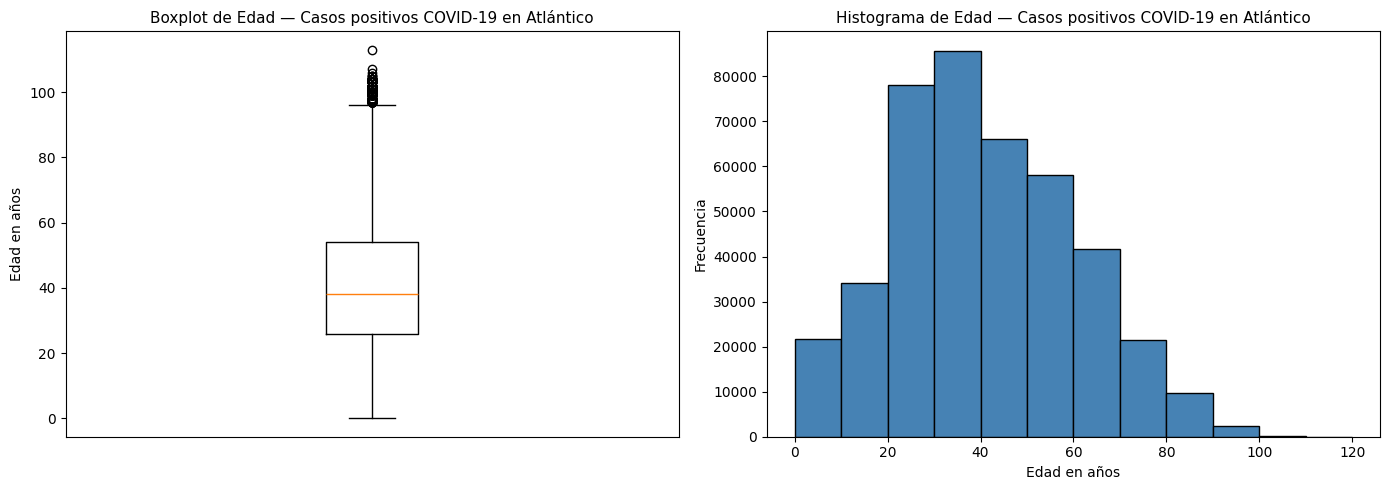

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
axes[0].boxplot(df["Edad_años"].dropna())
axes[0].set_title("Boxplot de Edad — Casos positivos COVID-19 en Atlántico", fontsize=11)
axes[0].set_ylabel("Edad en años")
axes[0].set_xticks([])

# Histograma
axes[1].hist(
    df["Edad_años"].dropna(),
    bins=np.arange(0, df["Edad_años"].max() + 10, 10),
    edgecolor="black", color="steelblue"
)
axes[1].set_title("Histograma de Edad — Casos positivos COVID-19 en Atlántico", fontsize=11)
axes[1].set_xlabel("Edad en años")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

A partir de las gráficas se puede observar que la mayor proporción de casos positivos de COVID-19 corresponde a personas con edades aproximadamente entre los 30 y 40 años. El boxplot muestra varios valores atípicos en edades avanzadas, lo que indica que aunque la mayoría de casos se concentró en adultos jóvenes y de mediana edad, también se presentaron contagios en personas mayores de 80 años.

### 12.2 Evolución Temporal de Casos

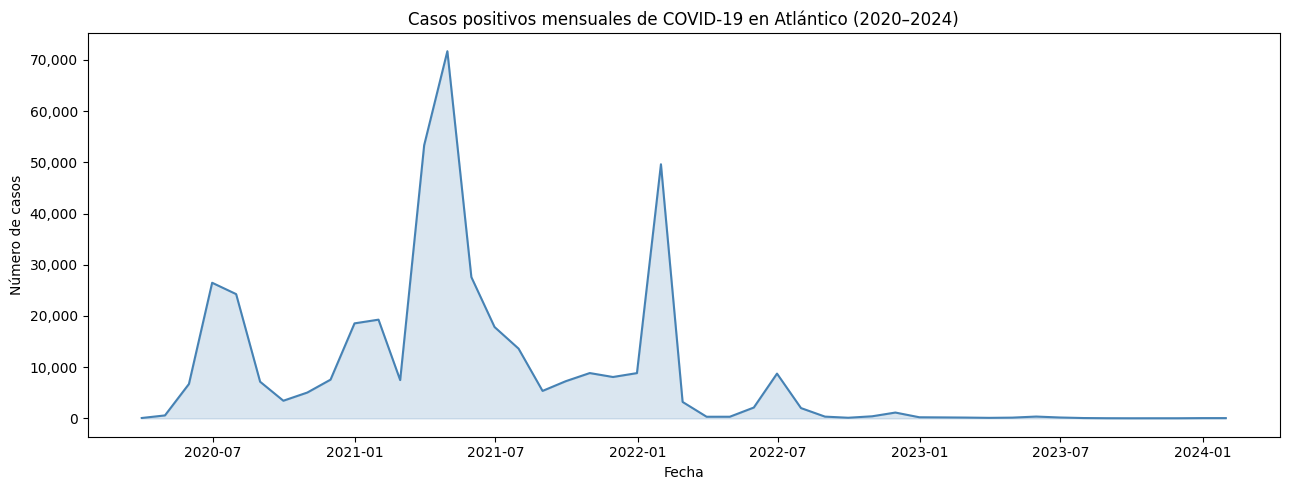

In [13]:
df["Fecha de notificacion"] = pd.to_datetime(df["Fecha de notificacion"])
fecha_notificaciones = (
    df.set_index("Fecha de notificacion")
      .resample("M")
      .size()
)

plt.figure(figsize=(13, 5))
plt.plot(fecha_notificaciones, color="steelblue", linewidth=1.5)
plt.fill_between(fecha_notificaciones.index, fecha_notificaciones.values, alpha=0.2, color="steelblue")
plt.title("Casos positivos mensuales de COVID-19 en Atlántico (2020–2024)", fontsize=12)
plt.xlabel("Fecha")
plt.ylabel("Número de casos")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

In [14]:
# Tabla de casos por año y mes
tabla_casos = (
    df.groupby([
        df["Fecha de notificacion"].dt.year,
        df["Fecha de notificacion"].dt.month
    ])
    .size()
    .unstack(fill_value=0)
)

tabla_casos.columns = [
    "Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio",
    "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"
]
tabla_casos.index.name = "Año"

tabla_casos.style.format("{:,}").background_gradient(cmap='YlOrRd')

,Enero,Febrero,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre
Año,,,,,,,,,,,,
2020,0,0,71,575,"6,715","26,486","24,270","7,155","3,445","5,045","7,562","18,555"
2021,"19,279","7,477","53,350","71,715","27,589","17,837","13,620","5,363","7,261","8,849","8,080","8,839"
2022,"49,631","3,209",316,318,"2,115","8,740","2,009",341,120,406,"1,136",214
2023,186,156,101,144,353,173,64,29,19,22,22,49
2024,50,0,0,0,0,0,0,0,0,0,0,0


Por lo observado en la gráfica y en la tabla, hubo un pico de casos positivos durante marzo y abril de 2021, con 53.350 y 71.715 casos positivos respectivamente. También se puede observar que en 2023 los casos se redujeron considerablemente, evidenciando el control progresivo de la pandemia.

### 12.3 Casos por Municipio

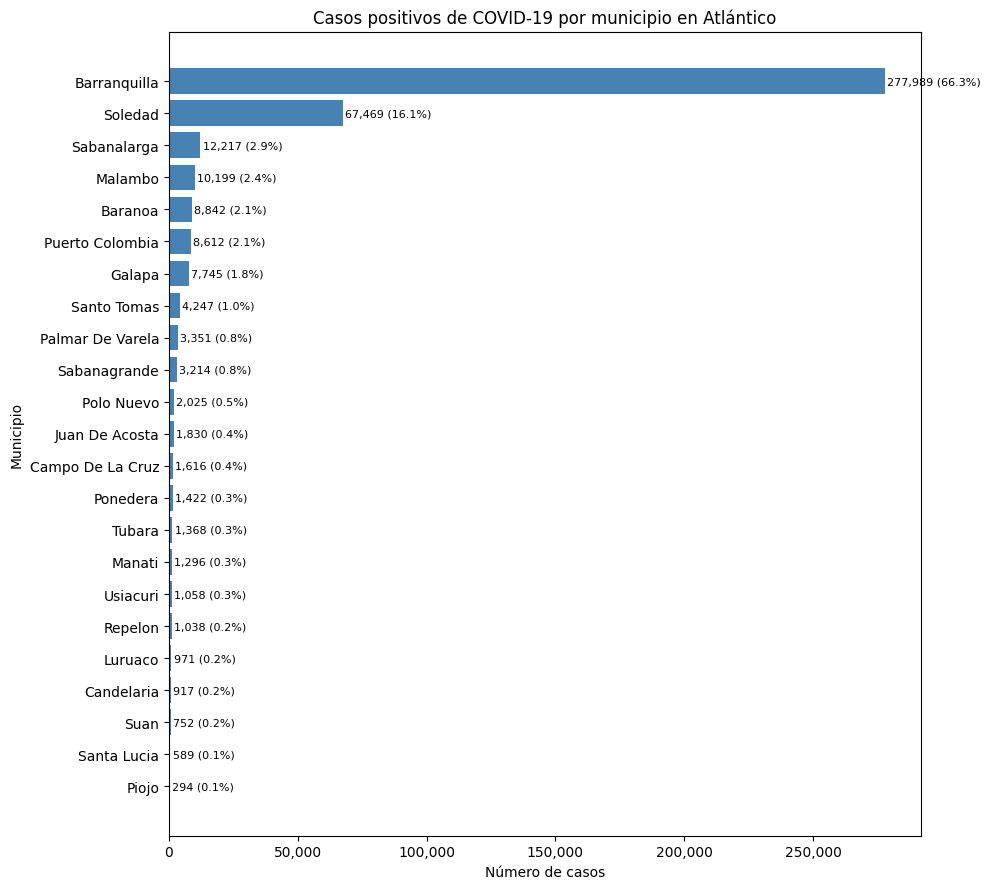

In [15]:
casos_municipio = (
    df.groupby("Nombre municipio")
    .size()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(casos_municipio.index, casos_municipio.values, color="steelblue")

# Agregar etiquetas con conteo y porcentaje en cada barra
total = casos_municipio.sum()
for bar, val in zip(bars, casos_municipio.values):
    pct = val / total * 100
    ax.text(
        bar.get_width() + total * 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,} ({pct:.1f}%)",
        va='center', ha='left', fontsize=8
    )

ax.set_title("Casos positivos de COVID-19 por municipio en Atlántico", fontsize=12)
ax.set_xlabel("Número de casos")
ax.set_ylabel("Municipio")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

A partir del gráfico de barras se puede observar que la gran mayoría de los casos positivos de COVID-19 se concentraron en Barranquilla, seguido por Soledad y Sabanalarga. Los municipios menos afectados por la pandemia fueron Pijao de Oro, Santa Lucía y Suán. Cada barra incluye el conteo absoluto y el porcentaje sobre el total de casos del departamento.

### 12.4 Tasa de Mortalidad por Municipio

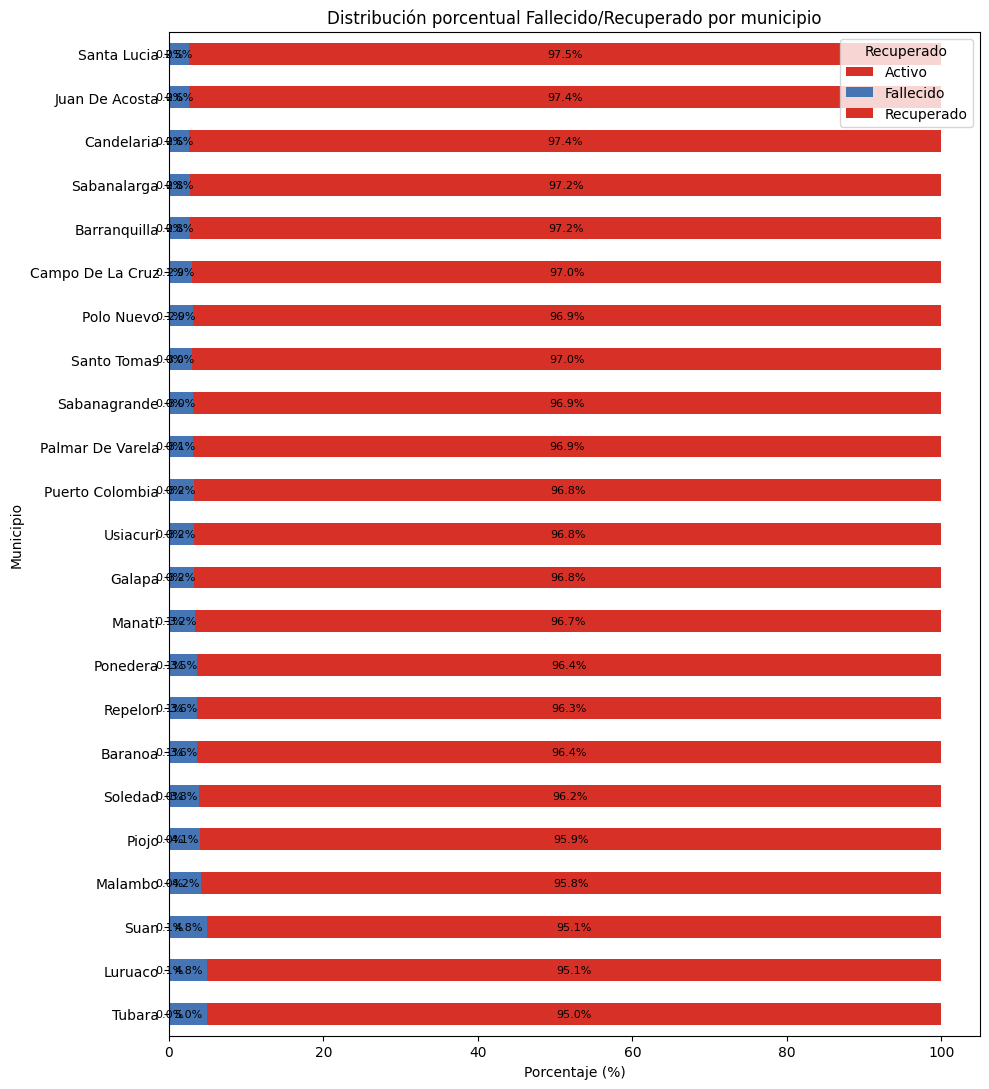

In [16]:
tabla = pd.crosstab(
    df["Nombre municipio"],
    df["Recuperado"],
    normalize="index"
) * 100

tabla = tabla.sort_values(by="Fallecido", ascending=False)

fig, ax = plt.subplots(figsize=(10, 11))
tabla.plot(
    kind="barh",
    stacked=True,
    figsize=(10, 11),
    ax=ax,
    color=["#d73027", "#4575b4"]
)

plt.title("Distribución porcentual Fallecido/Recuperado por municipio", fontsize=12)
plt.xlabel("Porcentaje (%)")
plt.ylabel("Municipio")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center", fontsize=8)

plt.tight_layout()
plt.show()

A través de esta gráfica se puede observar que el municipio con mejor manejo en la pandemia fue Santa Lucía con un 97.5% de recuperados. Juan de Acosta y Candelaria también presentaron bajas tasas de mortalidad con un 97.4% de recuperados. Por otro lado, Tubará fue el municipio más afectado en el Atlántico, llegando a una tasa de mortalidad del 5%.

### 12.5 Tipo de Contagio

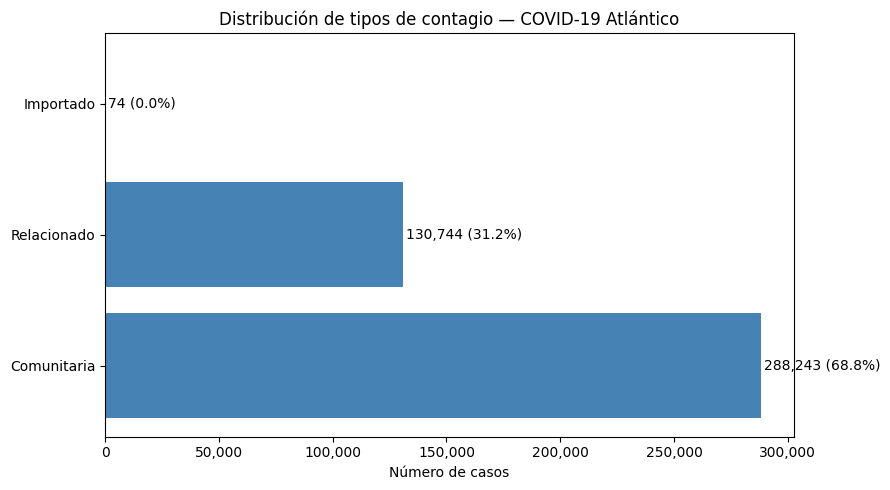

In [17]:
contagio_counts = df["Tipo de contagio"].value_counts()
total_contagio = contagio_counts.sum()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(contagio_counts.index, contagio_counts.values, color="steelblue")

for bar, val in zip(bars, contagio_counts.values):
    pct = val / total_contagio * 100
    ax.text(
        bar.get_width() + total_contagio * 0.003,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,} ({pct:.1f}%)",
        va='center', ha='left', fontsize=10
    )

ax.set_title("Distribución de tipos de contagio — COVID-19 Atlántico", fontsize=12)
ax.set_xlabel("Número de casos")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

Con base en los resultados, el tipo de contagio más común fue el **comunitario** con un 68%, es decir, cuando no se conoce la fuente exacta del contagio. La segunda forma más frecuente fue la "relacionada" con un 31%, en la que existe contacto directo con otra persona ya diagnosticada. Por último, la menos común fue la "importada", correspondiente a casos contagiados en el extranjero.

### 12.6 Distribución por Sexo

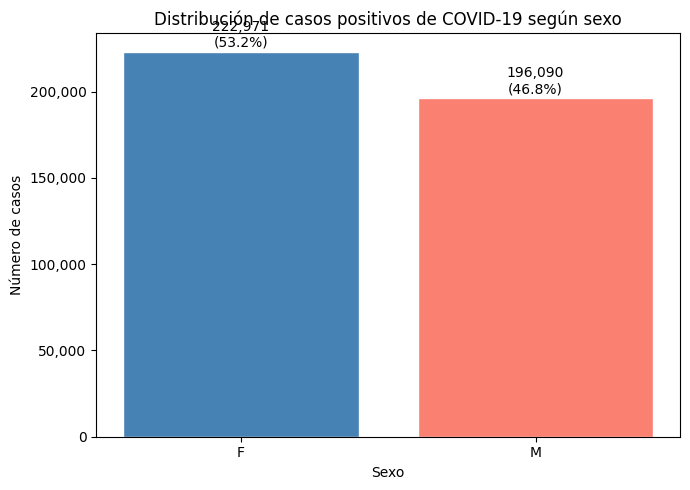

In [18]:
sexo = df["Sexo"].value_counts()
total_sexo = sexo.sum()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(sexo.index, sexo.values, color=["steelblue", "salmon"], edgecolor="white")

for bar, val in zip(bars, sexo.values):
    pct = val / total_sexo * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + total_sexo * 0.003,
        f"{val:,}\n({pct:.1f}%)",
        ha='center', va='bottom', fontsize=10
    )

ax.set_title("Distribución de casos positivos de COVID-19 según sexo", fontsize=12)
ax.set_xlabel("Sexo")
ax.set_ylabel("Número de casos")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

Se puede observar que hay mayor cantidad de casos positivos de COVID-19 en el género masculino, con un 53% del total de los casos en el Atlántico, mientras que las mujeres constituyeron el 46% de los contagiados.

### 12.7 Estado Final: Recuperados vs. Fallecidos

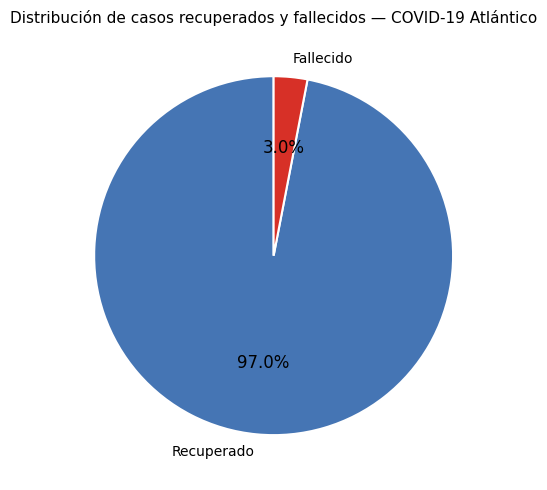

In [19]:
Caso_recuperado = (
    df["Recuperado"]
    .value_counts()
    .loc[["Recuperado", "Fallecido"]]
)

fig, ax = plt.subplots(figsize=(6, 5))
wedges, texts, autotexts = ax.pie(
    Caso_recuperado.values,
    labels=Caso_recuperado.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4575b4", "#d73027"],
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
for autotext in autotexts:
    autotext.set_fontsize(12)

ax.set_title("Distribución de casos recuperados y fallecidos — COVID-19 Atlántico", fontsize=11)
plt.tight_layout()
plt.show()

Según el gráfico circular, existe una tasa de mortalidad del **3%** en los casos positivos de COVID-19 en el Atlántico, mientras que el restante **97%** corresponde a los recuperados.

### 12.8 Días de Recuperación

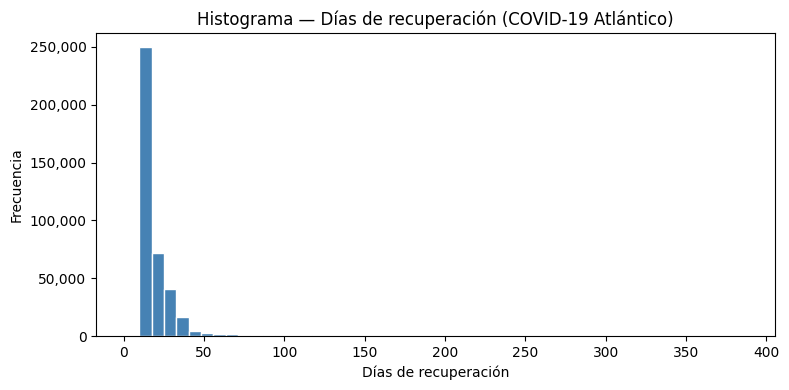

,Estadístico,Valor
0,N,"403,408"
1,Media,23.23
2,Desv. Estándar,28.58
3,Mínimo,2
4,Q1 (25%),14
5,Mediana (Q2),15
6,Q3 (75%),21
7,Máximo,386


In [20]:
plt.figure(figsize=(8, 4))
plt.hist(df["Dias de recuperacion"].dropna(), bins=50, color="steelblue", edgecolor="white")
plt.xlabel("Días de recuperación")
plt.ylabel("Frecuencia")
plt.title("Histograma — Días de recuperación (COVID-19 Atlántico)")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

# Tabla estadística
stats = df["Dias de recuperacion"].describe()
tabla_dias_rec = pd.DataFrame({
    "Estadístico": ["N", "Media", "Desv. Estándar", "Mínimo", "Q1 (25%)", "Mediana (Q2)", "Q3 (75%)", "Máximo"],
    "Valor": [
        f"{int(stats['count']):,}",
        f"{stats['mean']:.2f}",
        f"{stats['std']:.2f}",
        f"{int(stats['min'])}",
        f"{int(stats['25%'])}",
        f"{int(stats['50%'])}",
        f"{int(stats['75%'])}",
        f"{int(stats['max'])}"
    ]
})
tabla_dias_rec.style.set_properties(**{'text-align': 'center'}).set_table_styles(
    [{'selector': 'th', 'props': [('background-color', '#2c7bb6'), ('color', 'white'), ('text-align', 'center')]}]
)

En el histograma se puede observar que la distribución de días de recuperación presenta una asimetría positiva (sesgo a la derecha). El 50% de los pacientes tardó entre 14 y 21 días en recuperarse. La media de 23 días supera la mediana de 15 días, lo que evidencia la influencia de casos con recuperación muy prolongada (hasta 386 días). La mediana es la medida de tendencia central más adecuada para describir el comportamiento típico de esta variable.

### 12.9 Días hasta Fallecimiento

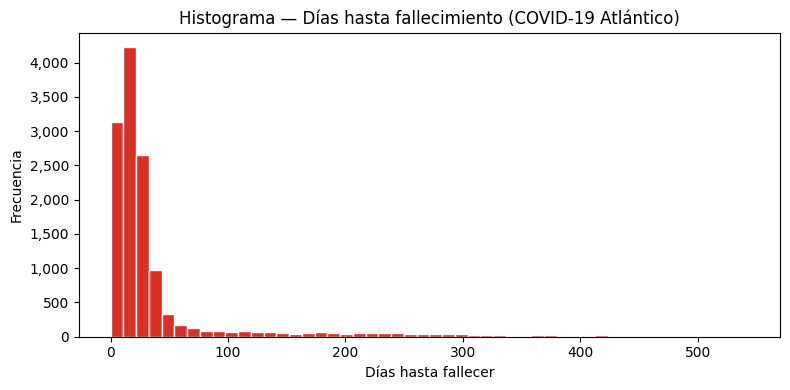

,Estadístico,Valor
0,N,"13,130"
1,Media,42.41
2,Desv. Estándar,74.91
3,Mínimo,0
4,Q1 (25%),11
5,Mediana (Q2),19
6,Q3 (75%),31
7,Máximo,543


In [21]:
plt.figure(figsize=(8, 4))
plt.hist(df["dias hasta fallecimiento"].dropna(), bins=50, color="#d73027", edgecolor="white")
plt.xlabel("Días hasta fallecer")
plt.ylabel("Frecuencia")
plt.title("Histograma — Días hasta fallecimiento (COVID-19 Atlántico)")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

# Tabla estadística
stats2 = df["dias hasta fallecimiento"].describe()
tabla_dias_fall = pd.DataFrame({
    "Estadístico": ["N", "Media", "Desv. Estándar", "Mínimo", "Q1 (25%)", "Mediana (Q2)", "Q3 (75%)", "Máximo"],
    "Valor": [
        f"{int(stats2['count']):,}",
        f"{stats2['mean']:.2f}",
        f"{stats2['std']:.2f}",
        f"{int(stats2['min'])}",
        f"{int(stats2['25%'])}",
        f"{int(stats2['50%'])}",
        f"{int(stats2['75%'])}",
        f"{int(stats2['max'])}"
    ]
})
tabla_dias_fall.style.set_properties(**{'text-align': 'center'}).set_table_styles(
    [{'selector': 'th', 'props': [('background-color', '#2c7bb6'), ('color', 'white'), ('text-align', 'center')]}]
)

Al igual que en la distribución de días de recuperación, la distribución de días hasta fallecimiento presenta una fuerte asimetría positiva. La mayoría de los casos se concentra entre 11 y 31 días. La media es mayor que la mediana debido a valores atípicos en la cola derecha que alcanzan hasta 543 días. Se toma la mediana (19 días) como la mejor medida de tendencia central.

### 12.10 Correlación entre Variables Numéricas

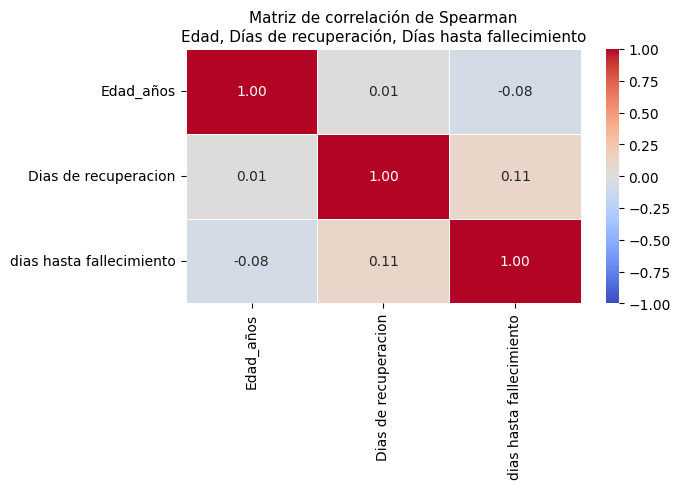

In [22]:
plt.figure(figsize=(7, 5))
corr_matrix = df[["Edad_años", "Dias de recuperacion", "dias hasta fallecimiento"]].corr(method="spearman")
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title("Matriz de correlación de Spearman\nEdad, Días de recuperación, Días hasta fallecimiento", fontsize=11)
plt.tight_layout()
plt.show()

La matriz de correlación entre las variables cuantitativas (edad, días hasta fallecimiento y días de recuperación) muestra que **no existe correlación significativa** entre ellas. El objetivo principal de este gráfico era verificar si la edad influye en el tiempo de recuperación o en el tiempo hasta fallecer de una persona infectada por COVID-19 en el Atlántico. Los resultados indican que no hay una asociación lineal monótona relevante entre estas variables a nivel poblacional.

---

## 13. Conclusiones

1. **Distribución demográfica:** La mayoría de casos positivos correspondió a personas de entre 30 y 40 años, con un leve predominio del sexo masculino (53%).

2. **Evolución temporal:** Se identificaron picos marcados en marzo y abril de 2021, con más de 70.000 casos en un solo mes. A partir de 2023, los casos se redujeron considerablemente.

3. **Distribución geográfica:** Barranquilla concentró la gran mayoría de los casos dado su peso poblacional. A nivel de mortalidad, Tubará presentó la tasa más alta, mientras que Santa Lucía tuvo el mejor desempeño relativo.

4. **Tipo de contagio:** El contagio comunitario fue el más frecuente (68%), lo que refleja la dificultad de rastrear el origen de los contagios durante la pandemia.

5. **Desenlace clínico:** El 97% de los casos registrados se recuperaron. El tiempo mediano de recuperación fue de 15 días y el de fallecimiento de 19 días desde el inicio de síntomas.

6. **Correlación:** No se encontró correlación significativa entre la edad del paciente y el tiempo de recuperación o el tiempo hasta el fallecimiento, lo que sugiere que otros factores (como comorbilidades o acceso al sistema de salud) podrían ser más determinantes.